In [18]:
!pip install sentence-transformers

In [19]:
from sentence_transformers import SentenceTransformer
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [20]:
sentences = [
    # Cricket
    "The captain declared the innings after setting a strong target",
    "The fast bowler delivered a perfect yorker to dismiss the batsman",
    "The team celebrated their victory after a thrilling last over finish",

    # Cooking
    "Marinating the ingredients enhances the taste of the dish",
    "The chef prepared a delicious meal using fresh herbs",
    "Boiling the pasta until it gives the perfect texture",

    # Cybersecurity
    "Two-factor authentication adds an extra layer of security",
    "Hackers often exploit vulnerabilities in outdated systems",
    "Regular software updates help prevent security breaches",
    "Malware can damage systems and steal sensitive information"
]

In [21]:
model = SentenceTransformer('all-MiniLM-L6-v2')
embeddings = model.encode(sentences)

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


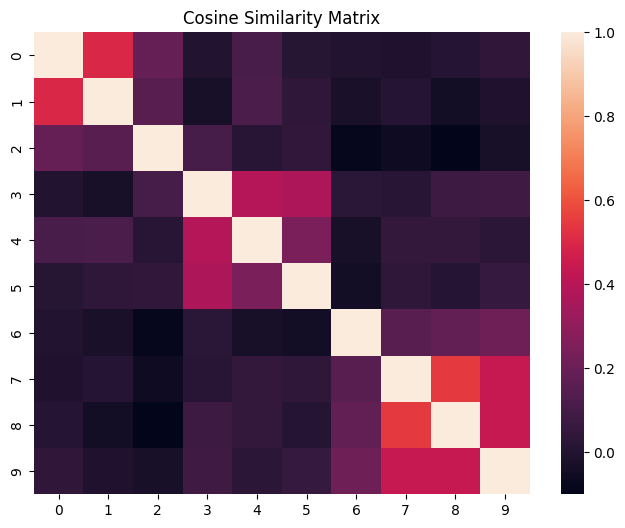

In [22]:
from sklearn.metrics.pairwise import cosine_similarity

similarity_matrix = cosine_similarity(embeddings)

plt.figure(figsize=(8,6))
sns.heatmap(similarity_matrix, annot=False)
plt.title("Cosine Similarity Matrix")
plt.show()


In [23]:
query = "The bowler took three wickets in one over"
query_embedding = model.encode([query])

similarities = cosine_similarity(query_embedding, embeddings)[0]

# Get top 2 similar sentences
top_indices = similarities.argsort()[-2:][::-1]

for idx in top_indices:
    print(f"Sentence: {sentences[idx]}")
    print(f"Similarity Score: {similarities[idx]}")
    print()

Sentence: The fast bowler delivered a perfect yorker to dismiss the batsman
Similarity Score: 0.5857612490653992

Sentence: The captain declared the innings after setting a strong target
Similarity Score: 0.4860893487930298

